In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from modules import data_loader, metrics, learning, plotting, utils, params, pipelines
from models.gmp import GMP, GMPTensor, GMPCP, BaseModel
import matplotlib.pyplot as plt
import numpy as np
import torch
import pandas as pd

Load data from files

In [3]:
# dataset_path = "datasets/Custom_dataset"
dataset_path = "datasets/DPA_200MHz"
# dataset_path = "datasets/Huawei_dataset"
# dataset_path = "datasets/signal_samples_newPA_vo_filter_no_atten_-11_dBm"
dataset_path = "datasets/dataset_87405C_-16dBm"


container = data_loader.DataContainer()
container.load_data(file_path=dataset_path)
container.get_gained_signals()

print(f"gain: {container.gain}")

acpr_meter = metrics.ACPR(
        sample_rate=container.input_signal_fs,
        main_measurement_bandwidth=container.bw_main_ch,
        adjacent_channel_offset=[-container.sub_ch, container.sub_ch],
        segment_length=container.nperseg,
        overlap_percentage=60,
        window='blackmanharris',
        fft_length=container.nperseg,
        power_units='dBW',
        return_main_power=True,
        return_adjacent_powers=True
    )

gain = container.get_gain()
# gain = 1

x_train = container.train_input
x_val = container.val_input
y_train = container.train_output
y_val = container.val_output


gain: 74.56969451904297


Algorithm 3 ALS algorithm for the identification of GMP-CP model

In [5]:
R=2
M1=5
M2=5
P=3
N=1024

gamma = 1e-2
L = 50
# torch.manual_seed(42)

model = GMPCP(R=R, M1=M1, M2=M2, P=P, model_name='pa')

N_delay = len(container.train_input) - max(M1, M2) + 1

y_vec, H, M = data_loader.prepare_data_for_als(x=x_train,
                                               y=y_train,
                                               M1=M1,
                                               M2=M2,
                                               P=P,
                                               N=N,)


model = learning.als_identification_of_gmpcp(model,
                                    y_vec=y_vec,
                                    H=H,
                                    M=M,
                                    N=N,
                                    L=L,
                                    gamma=gamma)

# model.save_weights()

In [6]:
x_train = utils.iq_to_complex(x_train)
x_val = utils.iq_to_complex(x_val)

y_train_pa = model(x_train)
y_val_pa = model(x_val)

delay = max(model.M1, model.M2) - 1

y_true_train = utils.iq_to_complex(y_train[delay:])
y_true_val = utils.iq_to_complex(y_val[delay:])

gmpcp_val_nmse = metrics.compute_nmse(y_val_pa, y_true_val)
print(F"NMSE val: {gmpcp_val_nmse:.2f} dB")

gmpcp_train_nmse = metrics.compute_nmse(y_train_pa, y_true_train)
print(F"NMSE train: {gmpcp_train_nmse:.2f} dB")

gmpcp_acepr = metrics.compute_acepr(
    measured=y_true_val,
    predicted=y_val_pa,
    fs=container.input_signal_fs,
    main_bandwidth=container.bw_main_ch,
    adjacent_bandwidth=container.bw_main_ch,
    channel_offset=container.bw_main_ch,
    nperseg=container.nperseg
)

print(f"ACEPR: {gmpcp_acepr:.2f} dB")

NMSE val: -21.17 dB
NMSE train: -35.06 dB
ACEPR: -43.59 dB


In [7]:
container.to_complex()


with torch.autograd.profiler.profile(use_cuda=False) as prof:
    with torch.no_grad():
        output = model.forward(container.val_input)

print(prof.key_averages().table(sort_by="cpu_time_total", row_limit=20))

------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
                    Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg    # of Calls  
------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
               aten::abs        13.12%     408.300us        32.85%       1.023ms     511.300us             2  
            aten::arange        12.80%     398.500us        29.35%     913.800us     456.900us             2  
            aten::einsum         1.93%      60.000us        22.99%     715.600us     357.800us             2  
             aten::index        10.27%     319.600us        10.76%     335.100us     167.550us             2  
           aten::reshape         9.81%     305.300us        10.75%     334.500us      55.750us             6  
               aten::bmm         6.60%     205.600us         8.03%     249.900us     124.950us             2  
 

c:\Users\maximp\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\signal\_spectral_py.py:652: UserWarning: Input data is complex, switching to return_onesided=False
  freqs, Pxx = csd(x, x, fs=fs, window=window, nperseg=nperseg,


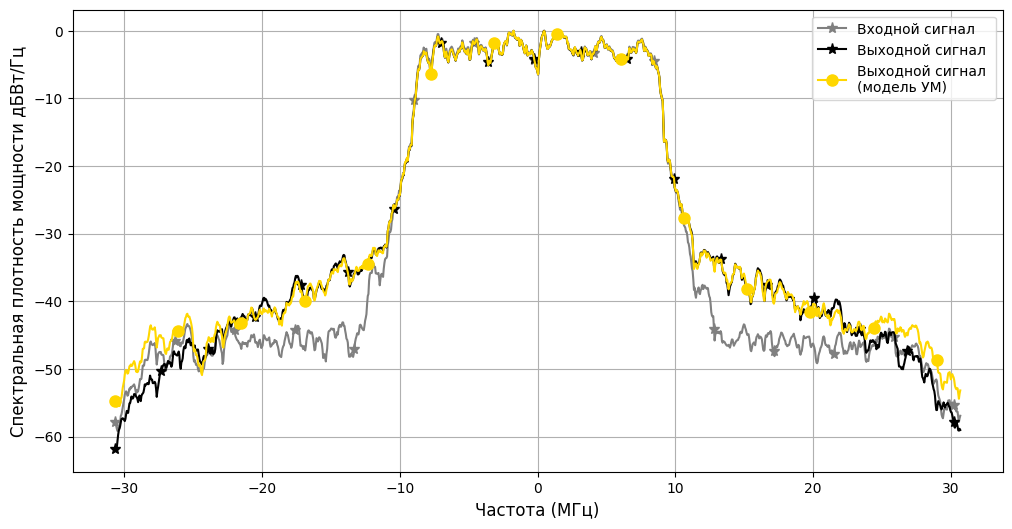

In [8]:
window_size = 10
normalization = True

freqs, spectrum_y_in = metrics.power_spectrum(x_val[delay:], container.input_signal_fs, container.nperseg, window_size, normalization=normalization)
_, spectrum_y_out = metrics.power_spectrum(y_true_val, container.input_signal_fs, container.nperseg, window_size, normalization=normalization)
_, spectrum_y_val_pa = metrics.power_spectrum(y_val_pa, container.input_signal_fs, container.nperseg, window_size, normalization=normalization)

xlabel="Частота (МГц)"
ylabel= "Спектральная плотность мощности дБВт/Гц"
fontsize = 12
figsize=(12, 6)
markersize=8

plt.figure(figsize=figsize)

plt.plot(freqs / 1e6, spectrum_y_in, color='grey', label='Входной сигнал', marker = '*', markevery=90, markersize=markersize)
plt.plot(freqs / 1e6, spectrum_y_out, color='black', label='Выходной сигнал', marker = '*', markevery=70, markersize=markersize)
plt.plot(freqs / 1e6, spectrum_y_val_pa, color='gold', label='Выходной сигнал \n(модель УМ)', marker='o', markevery=95, markersize=markersize)

plt.xlabel(xlabel, fontsize=fontsize)
plt.ylabel(ylabel, fontsize=fontsize)
# plt.ylim(bottom=-122)
# plt.xticks(np.arange(-500, 600, 100))
plt.legend()
plt.grid()
plt.show()


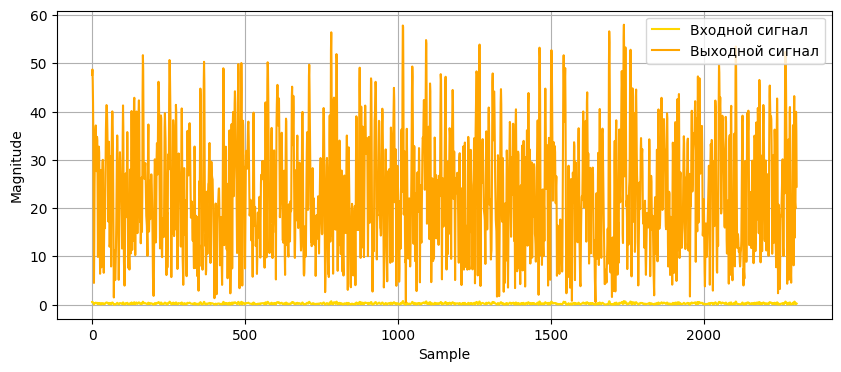

In [10]:
x_val_t = torch.abs(utils.iq_to_complex(x_val[delay:]))
y_true_val_t = torch.abs(y_true_val)

plt.figure(figsize=(10,4))
plt.plot(x_val_t, color='gold', label='Входной сигнал')
plt.plot(y_true_val_t, color='orange', label='Выходной сигнал')
plt.xlabel("Sample")
plt.ylabel("Magnitude")
plt.legend()
plt.grid(True)
plt.show()

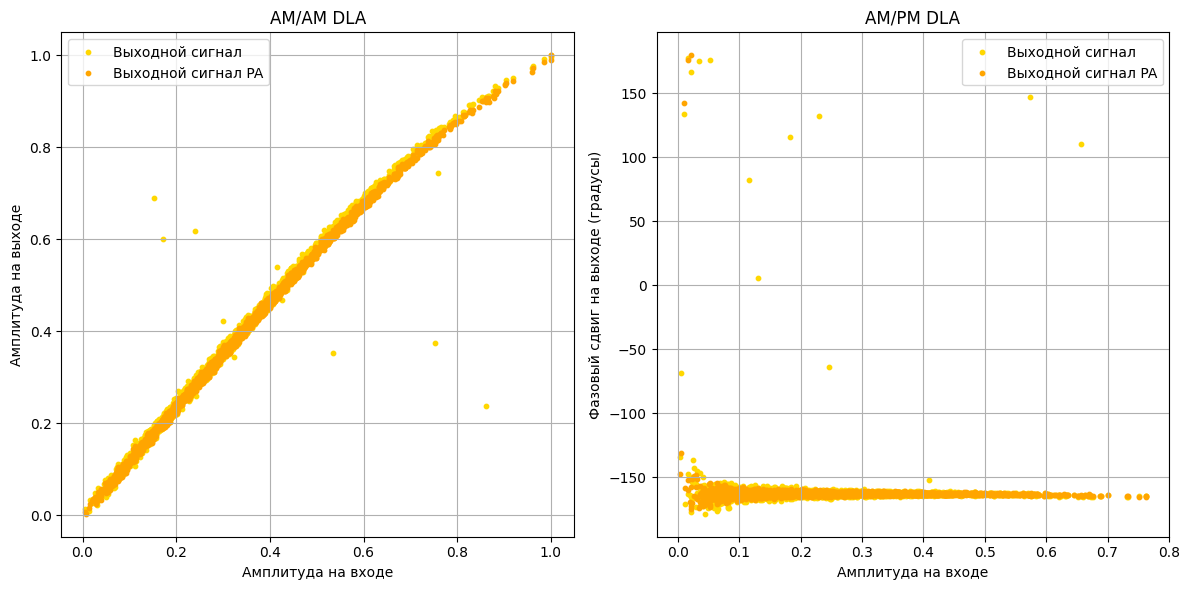

In [11]:
x_am_am, y_am_am = metrics.calculate_am_am(x_val[delay:], y_true_val)
x_am_pm, x_phase_am_pm = metrics.calculate_am_pm(x_val[delay:], y_true_val)

_, y_pa_am_am = metrics.calculate_am_am(x_val[delay:], y_val_pa)
_, y_pa_phase_am_pm = metrics.calculate_am_pm(x_val[delay:], y_val_pa)

am_am_data = [
    (x_am_am, y_am_am, 'gold', 'Выходной сигнал'),
    (x_am_am, y_pa_am_am, 'orange', 'Выходной сигнал PA'),
]

am_pm_data = [
    (x_am_pm, x_phase_am_pm, 'gold', 'Выходной сигнал'),
    (x_am_pm, y_pa_phase_am_pm, 'orange', 'Выходной сигнал PA'),
]

plotting.plot_am_am_pm(
    am_am_data=am_am_data,
    am_pm_data=am_pm_data,
    figsize=(12, 6),
    titles=("AM/AM DLA", "AM/PM DLA"),
    xlabels=("Амплитуда на входе", "Амплитуда на входе"),
    ylabels=("Амплитуда на выходе", "Фазовый сдвиг на выходе (градусы)")
)



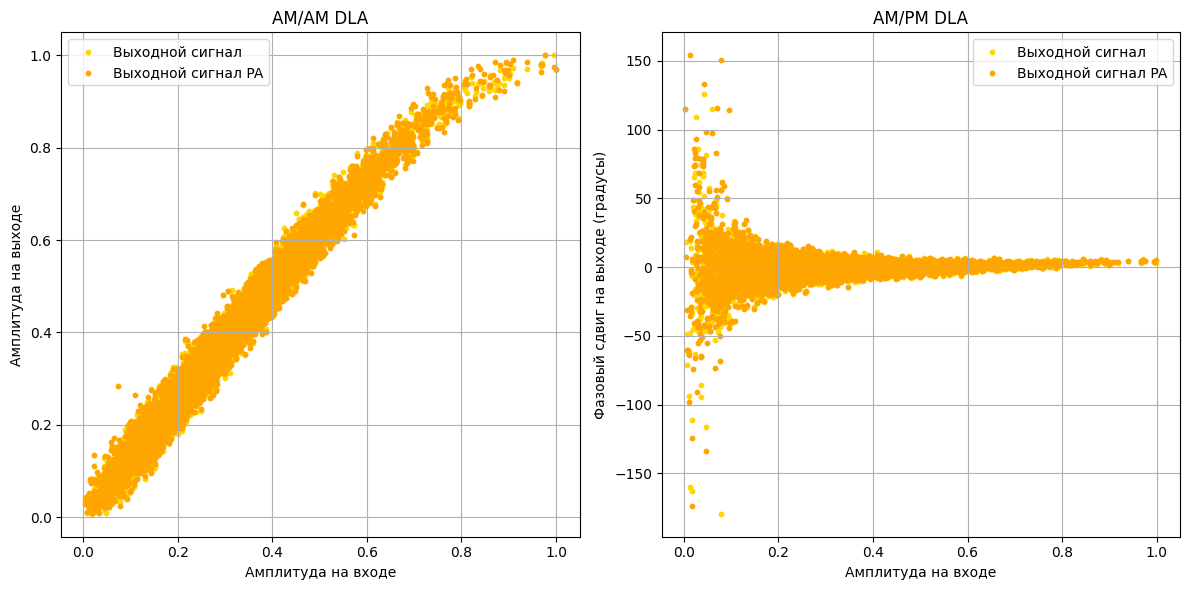

In [74]:
x_am_am, y_am_am = metrics.calculate_am_am(x_val[delay:], y_true_val)
x_am_pm, x_phase_am_pm = metrics.calculate_am_pm(x_val[delay:], y_true_val)

_, y_pa_am_am = metrics.calculate_am_am(x_val[delay:], y_val_pa)
_, y_pa_phase_am_pm = metrics.calculate_am_pm(x_val[delay:], y_val_pa)

am_am_data = [
    (x_am_am, y_am_am, 'gold', 'Выходной сигнал'),
    (x_am_am, y_pa_am_am, 'orange', 'Выходной сигнал PA'),
]

am_pm_data = [
    (x_am_pm, x_phase_am_pm, 'gold', 'Выходной сигнал'),
    (x_am_pm, y_pa_phase_am_pm, 'orange', 'Выходной сигнал PA'),
]

plotting.plot_am_am_pm(
    am_am_data=am_am_data,
    am_pm_data=am_pm_data,
    figsize=(12, 6),
    titles=("AM/AM DLA", "AM/PM DLA"),
    xlabels=("Амплитуда на входе", "Амплитуда на входе"),
    ylabels=("Амплитуда на выходе", "Фазовый сдвиг на выходе (градусы)")
)



In [ ]:

def collect_als_statistics(main_model, M1, M2, P, R_range, num_runs, L, gamma, N, dataset_names_range, use_even_powers: bool = False):
    result_list = []
    
    for dataset_name in dataset_names_range:
        print(f"Dataset: {dataset_name}")
        
        dataset_path = f"datasets/{dataset_name}"
        container = data_loader.DataContainer()
        container.load_data(file_path=dataset_path)
        container.get_gained_signals()
        print(f"gain: {container.gain}")
        y_vec, H, M = data_loader.prepare_data_for_als(x=container.train_input,
                                    y=container.train_output,
                                    M1=M1,
                                    M2=M2,
                                    P=P,
                                    N=N,
                                )
        
        x = utils.iq_to_complex(container.val_input_orig)
        delay = max(model.M1, model.M2) - 1

        for R in R_range:
            print(f"R: {R}")

            for n in range(num_runs):
                print(f"Run: {n}")
                seed = hash((dataset_name, R, n)) % (2**32)
                torch.manual_seed(seed)
                model = main_model(R=R, M1=M1, M2=M2, P=P)
                
                model = learning.als_identification_of_gmpcp(model,
                                    y_vec=y_vec,
                                    H=H,
                                    M=M,
                                    N=N,
                                    L=L,
                                    gamma=gamma)

                y_pred = model(x)

                y_true = utils.iq_to_complex(container.val_output[delay:])

                gmpcp_nmse = metrics.compute_nmse(y_pred, y_true)
                print(F"NMSE: {gmpcp_nmse:.2f} dB")

                gmpcp_acepr = metrics.compute_acepr(
                    measured=y_true,
                    predicted=y_pred,
                    fs=container.input_signal_fs,
                    main_bandwidth=container.bw_main_ch,
                    adjacent_bandwidth=container.bw_main_ch,
                    channel_offset=container.bw_main_ch,
                    nperseg=container.nperseg
                )

                print(f"ACEPR: {gmpcp_acepr:.2f} dB")
                
                result_list.append({
                    'dataset': dataset_name,
                    'R': R,
                    'run': n,
                    'nmse': float(gmpcp_nmse),
                    'acepr': float(gmpcp_acepr),
                })
    
    return result_list

In [ ]:
main_model = GMPCP
M1=11
M2=10
P=8
N=8196
gamma = 1e-2
L = 20

R_range = [1, 2, 3, 4, 5]
num_runs = 50
dataset_names_range = ('DPA_200MHz', 
                       'Custom_dataset', 
                       'Huawei_dataset',
                       'signal_samples_newPA_vo_filter_no_atten_-11_dBm',
                       'signal_samples_newPA_vo_filter_no_atten_-12_dBm',
                       'signal_samples_newPA_vo_filter_no_atten_-13_dBm',
                       'signal_samples_newPA_vo_filter_no_atten_-14_dBm',
                       'signal_samples_newPA_vo_filter_no_atten_-15_dBm',
                       'signal_samples_newPA_vo_filter_no_atten_-15_dBm',
                       'signal_samples_newPA_vo_filter_no_atten_-16_dBm',
                       'signal_samples_newPA_vo_filter_no_atten_-17_dBm',
                       )


result_list_odd = collect_als_statistics(main_model=main_model,
                       M1=M1,
                       M2=M2, 
                       P=P,
                       R_range=R_range,
                       num_runs=num_runs,
                       L=L,
                       gamma=gamma,
                       N=N,
                       dataset_names_range=dataset_names_range,)

Dataset: DPA_200MHz
gain: 2.5208089351654053
R: 1
Run: 0
NMSE: -31.17 dB
ACEPR: -37.82 dB
Run: 1
NMSE: -31.36 dB
ACEPR: -38.16 dB
Run: 2
NMSE: -30.99 dB
ACEPR: -37.78 dB
Run: 3
NMSE: -31.32 dB
ACEPR: -38.08 dB
Run: 4
NMSE: -28.52 dB
ACEPR: -36.38 dB
Run: 5
NMSE: -31.15 dB
ACEPR: -37.93 dB
Run: 6
NMSE: -31.38 dB
ACEPR: -38.18 dB
Run: 7
NMSE: -29.07 dB
ACEPR: -36.44 dB
Run: 8
NMSE: -29.36 dB
ACEPR: -36.74 dB
Run: 9
NMSE: -31.36 dB
ACEPR: -38.18 dB
Run: 10
NMSE: -30.73 dB
ACEPR: -37.49 dB
Run: 11
NMSE: -30.01 dB
ACEPR: -35.74 dB
Run: 12
NMSE: -31.34 dB
ACEPR: -38.13 dB
Run: 13
NMSE: -29.24 dB
ACEPR: -36.65 dB
Run: 14
NMSE: -31.17 dB
ACEPR: -37.92 dB
Run: 15
NMSE: -31.24 dB
ACEPR: -37.96 dB
Run: 16
NMSE: -31.33 dB
ACEPR: -38.12 dB
Run: 17
NMSE: -31.10 dB
ACEPR: -37.68 dB
Run: 18
NMSE: -31.35 dB
ACEPR: -38.13 dB
Run: 19
NMSE: -31.35 dB
ACEPR: -38.15 dB
Run: 20
NMSE: -27.77 dB
ACEPR: -36.79 dB
Run: 21
NMSE: -30.99 dB
ACEPR: -37.73 dB
Run: 22
NMSE: -30.89 dB
ACEPR: -37.69 dB
Run: 23
NMSE: -31

In [18]:
from scipy import stats


def confidence_interval(values, confidence=0.95):
    values = np.asarray(values)

    if len(values) < 2:
        return 0.0

    sem = stats.sem(values)

    h = sem * stats.t.ppf(
        (1 + confidence) / 2,
        len(values) - 1
    )

    return h

def aggregate_measured_data(arrray):
    df = pd.DataFrame(arrray)
    grouped = df.groupby(['dataset', 'R'])
    df_agg = grouped.agg(
        nmse_mean=('nmse', 'mean'),
        nmse_std=('nmse', 'std'),
        nmse_count=('nmse', 'count'),
        nmse_ci=('nmse', confidence_interval),

        acepr_mean=('acepr', 'mean'),
        acepr_std=('acepr', 'std'),
        acepr_count=('acepr', 'count'),
        acepr_ci=('acepr', confidence_interval),
    ).reset_index()
    
    return df_agg

In [19]:

df_result_odd_agg = aggregate_measured_data(result_list_odd)
df_result_odd_agg.head()

,dataset,R,nmse_mean,nmse_std,nmse_count,nmse_ci,acepr_mean,acepr_std,acepr_count,acepr_ci
0,Custom_dataset,1,-28.148073,6.421311,50,1.824916,-34.252167,5.875999,50,1.669940
1,Custom_dataset,2,-36.819261,5.816649,50,1.653073,-42.758218,5.157090,50,1.465629
2,Custom_dataset,3,-40.770610,3.328941,50,0.946074,-45.055724,3.027595,50,0.860433
3,Custom_dataset,4,-41.660281,1.811381,50,0.514789,-45.756045,1.556558,50,0.442369
4,Custom_dataset,5,-41.469232,3.174186,50,0.902094,-45.652068,2.089527,50,0.593837


In [23]:
print(df_result_odd_agg.to_dict())

{'dataset': {0: 'Custom_dataset', 1: 'Custom_dataset', 2: 'Custom_dataset', 3: 'Custom_dataset', 4: 'Custom_dataset', 5: 'Custom_dataset', 6: 'DPA_200MHz', 7: 'DPA_200MHz', 8: 'DPA_200MHz', 9: 'DPA_200MHz', 10: 'DPA_200MHz', 11: 'DPA_200MHz', 12: 'Huawei_dataset', 13: 'Huawei_dataset', 14: 'Huawei_dataset', 15: 'Huawei_dataset', 16: 'Huawei_dataset', 17: 'Huawei_dataset', 18: 'signal_samples_newPA_vo_filter_no_atten_-11_dBm', 19: 'signal_samples_newPA_vo_filter_no_atten_-11_dBm', 20: 'signal_samples_newPA_vo_filter_no_atten_-11_dBm', 21: 'signal_samples_newPA_vo_filter_no_atten_-11_dBm', 22: 'signal_samples_newPA_vo_filter_no_atten_-11_dBm', 23: 'signal_samples_newPA_vo_filter_no_atten_-11_dBm', 24: 'signal_samples_newPA_vo_filter_no_atten_-12_dBm', 25: 'signal_samples_newPA_vo_filter_no_atten_-12_dBm', 26: 'signal_samples_newPA_vo_filter_no_atten_-12_dBm', 27: 'signal_samples_newPA_vo_filter_no_atten_-12_dBm', 28: 'signal_samples_newPA_vo_filter_no_atten_-12_dBm', 29: 'signal_samples_

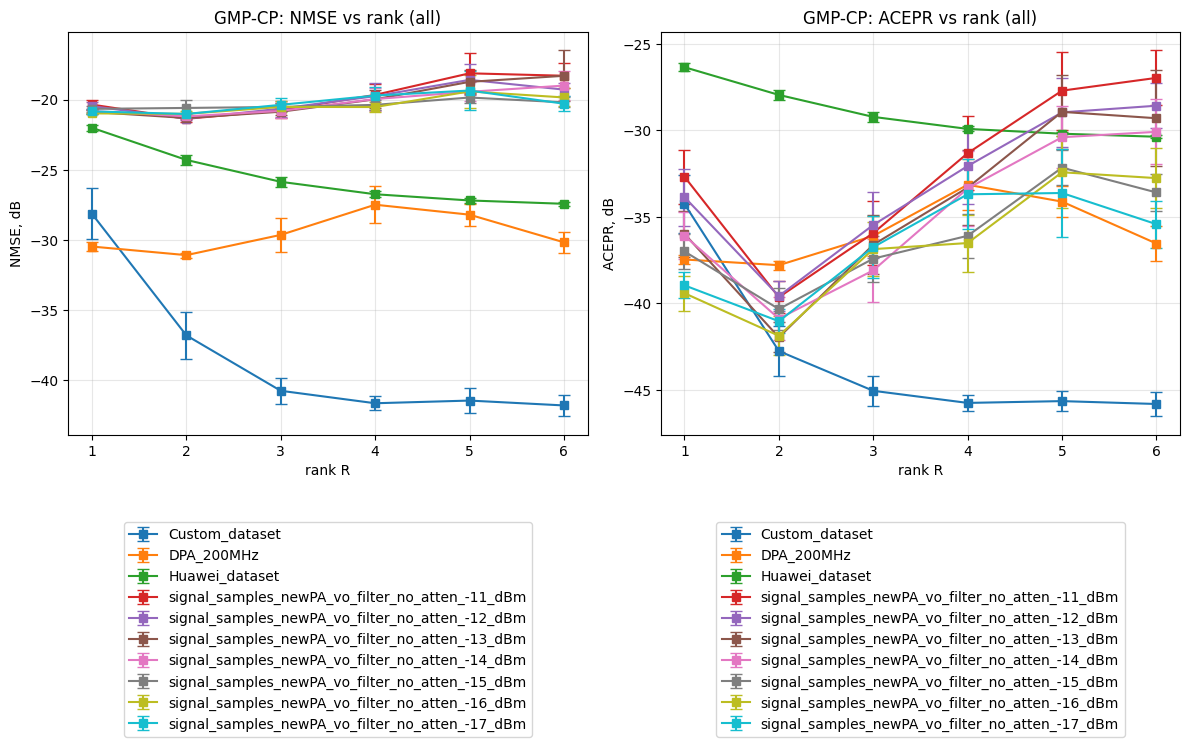

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 8))

for dataset_name, group in df_result_odd_agg.groupby('dataset'):

    group = group.sort_values('R')

    axes[0].errorbar(
        group['R'],
        group['nmse_mean'],
        yerr=group['nmse_ci'],
        marker='s',
        capsize=4,
        label=dataset_name
    )

    axes[1].errorbar(
        group['R'],
        group['acepr_mean'],
        yerr=group['acepr_ci'],
        marker='s',
        capsize=4,
        label=dataset_name
    )


axes[0].set_xlabel("rank R")
axes[0].set_ylabel("NMSE, dB")
axes[0].set_title("GMP-CP: NMSE vs rank (all)")
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(np.arange(1, 7, 1))
axes[0].legend(loc="upper center",bbox_to_anchor=(0.5, -0.2))
# axes[0].legend()


axes[1].set_xlabel("rank R")
axes[1].set_ylabel("ACEPR, dB")
axes[1].set_title("GMP-CP: ACEPR vs rank (all)")
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(np.arange(1, 7, 1))
axes[1].legend(loc="upper center",bbox_to_anchor=(0.5, -0.2))
# axes[1].legend()


plt.tight_layout()
plt.show()

Basic GMP

In [25]:
def prepare_data_for_gmp(x, M1, M2, P, N):
    x = utils.iq_to_complex(x)
    
    delay = max(M1, M2)-1
    
    n_idx = torch.arange(N)[:,None]
    i_idx = torch.arange(M1)[None,:]
    j_idx = torch.arange(M2)[None,:]
    powers = torch.arange(P)[None,None,:] * 2

    x_i = x[delay+n_idx-i_idx]
    x_j = x[delay+n_idx-j_idx]

    abs_xj = torch.abs(x_j)
    abs_powers = (abs_xj[:,:,None]**powers) # (N,M2,P)

    Phi = (x_i[:, :, None, None] * abs_powers[:, None, :, :]) # (N,M1,M2,P)
    Phi = Phi.reshape(N, M1 * M2 * P)

    return Phi

def identify_gmp(model,
                 x,
                 y,
                 M1,
                 M2,
                 P,
                 gamma=0):

    s = learning.ridge_ls(x, y, gamma)

    S = s.reshape(M1, M2, P)

    model.set_parameters(S)

    return model



In [26]:
M1=11
M2=10
P=8
N=1024

gamma = 0

container.to_complex()

x = prepare_data_for_gmp(x=container.train_input,
                                  M1=M1, 
                                  M2=M2, 
                                  P=P, 
                                  N=N)


model_gmp = GMPTensor(M1=M1, M2=M2, P=P)

delay = model_gmp.get_delay()

y_vec = container.train_output[delay:delay+N].to(torch.complex64)

model_gmp = identify_gmp(
    model_gmp,
    x,
    y_vec,
    M1,
    M2,
    P,
    gamma
)



NMSE: -10.31 dB
ACEPR: -7.84 dB


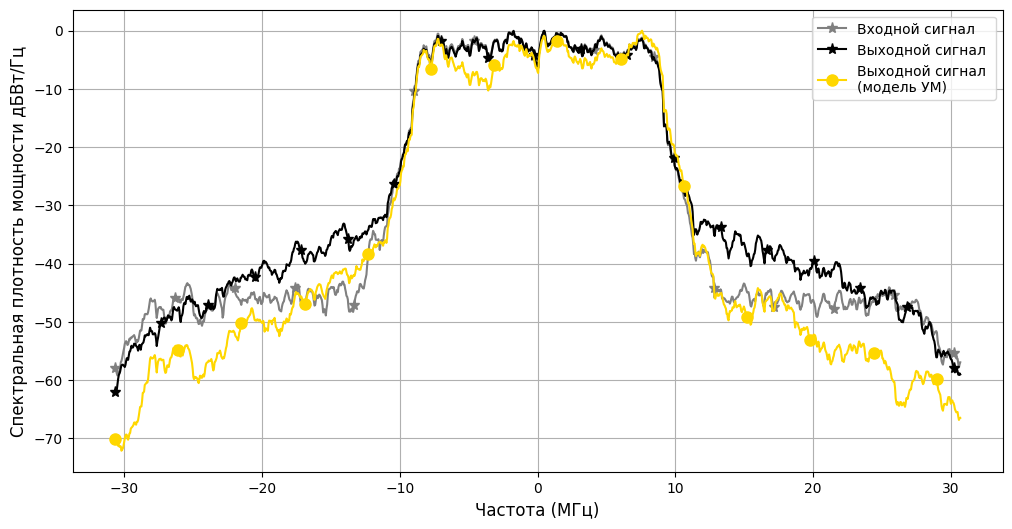

In [27]:
x_val = utils.iq_to_complex(container.val_input)

with torch.no_grad():
    y_val_pa = model_gmp(x_val)

y_true_val = utils.iq_to_complex(container.val_output[delay:])

gmp_nmse = metrics.compute_nmse(y_val_pa, y_true_val)
print(F"NMSE: {gmp_nmse:.2f} dB")

gmp_acepr = metrics.compute_acepr(
    measured=y_true_val,
    predicted=y_val_pa,
    fs=container.input_signal_fs,
    main_bandwidth=container.bw_main_ch,
    adjacent_bandwidth=container.bw_main_ch,
    channel_offset=1024,
    nperseg=container.nperseg
)

print(f"ACEPR: {gmp_acepr:.2f} dB")


window_size = 10

freqs, spectrum_y_in = metrics.power_spectrum(x_val[delay:], container.input_signal_fs, container.nperseg, window_size)
_, spectrum_y_out = metrics.power_spectrum(y_true_val, container.input_signal_fs, container.nperseg, window_size)
_, spectrum_y_val_pa = metrics.power_spectrum(y_val_pa, container.input_signal_fs, container.nperseg, window_size)

xlabel="Частота (МГц)"
ylabel= "Спектральная плотность мощности дБВт/Гц"
fontsize = 12
figsize=(12, 6)
markersize=8

plt.figure(figsize=figsize)

plt.plot(freqs / 1e6, spectrum_y_in, color='grey', label='Входной сигнал', marker = '*', markevery=90, markersize=markersize)
plt.plot(freqs / 1e6, spectrum_y_out, color='black', label='Выходной сигнал', marker = '*', markevery=70, markersize=markersize)
plt.plot(freqs / 1e6, spectrum_y_val_pa, color='gold', label='Выходной сигнал \n(модель УМ)', marker='o', markevery=95, markersize=markersize)

plt.xlabel(xlabel, fontsize=fontsize)
plt.ylabel(ylabel, fontsize=fontsize)
# plt.ylim(bottom=-122)
# plt.xticks(np.arange(-500, 600, 100))
plt.legend()
plt.grid()
plt.show()


In [34]:
M1 = 10
M2 = 10
P = 8

model_true = GMPTensor(
    M1=M1,
    M2=M2,
    P=P
)

S_true = torch.randn(
    M1,
    M2,
    P,
    dtype=torch.complex64
)

model_true.set_parameters(S_true)

x = utils.iq_to_complex(container.train_input)

with torch.no_grad():
    y = model_true(x)
    
Phi = prepare_data_for_gmp(
    x,
    M1,
    M2,
    P,
    N=len(y)
)

y_phi = Phi @ S_true.reshape(-1)

error = torch.max(torch.abs(y - y_phi))

print(error)

tensor(0.)


In [35]:
S_est_vec = learning.ridge_ls(
    Phi,
    y,
    gamma=1e-4
)

S_est = S_est_vec.reshape(
    M1,
    M2,
    P
)

coef_error = torch.norm(
    S_est - S_true
)

print("coef_error: ", coef_error)

y_est = Phi @ S_est.reshape(-1)

nmse = torch.norm(y_est - y)**2 / torch.norm(y)**2

print(
    "output NMSE:",
    10 * torch.log10(nmse)
)

coef_error:  tensor(224.2133)
output NMSE: tensor(-52.0969)


ILC

In [103]:
# dataset_path = "datasets/Custom_dataset"
# dataset_path = "datasets/DPA_200MHz"
# dataset_path = "datasets/Huawei_dataset"
dataset_path = "datasets/signal_samples_newPA_vo_filter_no_atten_-17_dBm"

container = data_loader.DataContainer()
container.load_data(file_path=dataset_path)
container.get_gained_signals()

print(f"gain: {container.gain}")

acpr_meter = metrics.ACPR(
        sample_rate=container.input_signal_fs,
        main_measurement_bandwidth=container.bw_main_ch,
        adjacent_channel_offset=[-container.sub_ch, container.sub_ch],
        segment_length=container.nperseg,
        overlap_percentage=60,
        window='blackmanharris',
        fft_length=container.nperseg,
        power_units='dBW',
        return_main_power=True,
        return_adjacent_powers=True
    )


gain: 69.86884307861328


In [143]:
R=3
M1=11
M2=10
P=8
N=2048

gamma = 1e-2
L = 10
# torch.manual_seed(42)

pa_model = GMPCP(R=R, M1=M1, M2=M2, P=P, model_name='pa')

delay = pa_model.max_delay

y_vec, H, M = data_loader.prepare_data_for_als(x=container.train_input,
                                    y=container.train_output,
                                    M1=M1,
                                    M2=M2,
                                    P=P,
                                    N=N,
                                )


pa_model = learning.als_identification_of_gmpcp(pa_model,
                                    y_vec=y_vec,
                                    H=H,
                                    M=M,
                                    N=N,
                                    L=L,
                                    gamma=gamma)

In [144]:
container.to_complex()
# container.to_iq()

y_val_pa = pa_model.forward(container.val_input)
# y_true = utils.iq_to_complex(container.val_output[delay:])

gmpcp_nmse = metrics.compute_nmse(y_val_pa, container.val_output[delay:])
print(F"NMSE: {gmpcp_nmse:.2f} dB")

# with torch.autograd.profiler.profile(use_cuda=False) as prof:
#     with torch.no_grad():
#         output = pa_model.forward(container.val_input)

# print(prof.key_averages().table(sort_by="cpu_time_total", row_limit=20))

NMSE: -21.19 dB


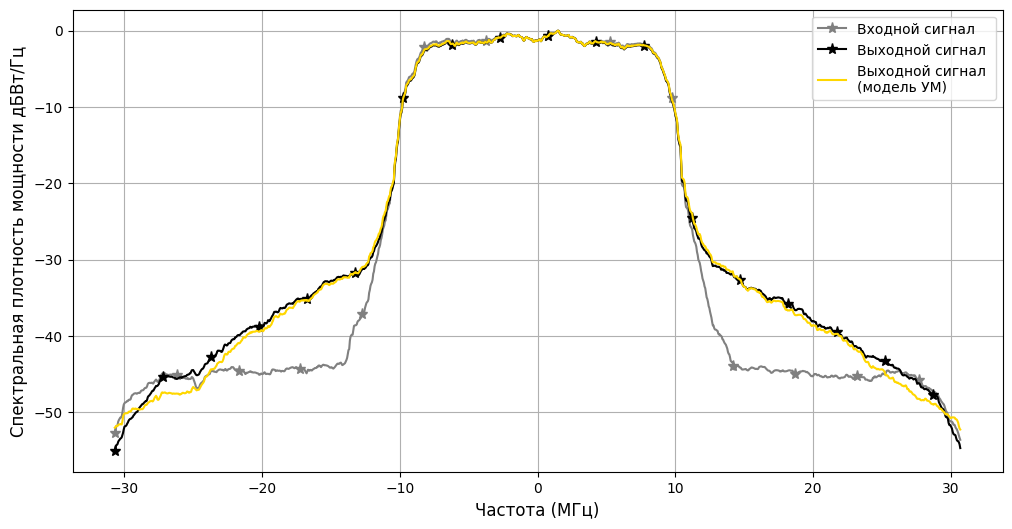

In [145]:
window_size = 50

freqs, spectrum_y_in = metrics.power_spectrum(container.val_input[delay:], container.input_signal_fs, container.nperseg, window_size)
_, spectrum_y_out = metrics.power_spectrum(container.val_output[delay:], container.input_signal_fs, container.nperseg, window_size)
_, spectrum_y_val_pa = metrics.power_spectrum(y_val_pa, container.input_signal_fs, container.nperseg, window_size)

xlabel="Частота (МГц)"
ylabel= "Спектральная плотность мощности дБВт/Гц"
fontsize = 12
figsize=(12, 6)
markersize=8

plt.figure(figsize=figsize)

plt.plot(freqs / 1e6, spectrum_y_in, color='grey', label='Входной сигнал', marker = '*', markevery=90, markersize=markersize)
plt.plot(freqs / 1e6, spectrum_y_out, color='black', label='Выходной сигнал', marker = '*', markevery=70, markersize=markersize)
plt.plot(freqs / 1e6, spectrum_y_val_pa, color='gold', label='Выходной сигнал \n(модель УМ)')



plt.xlabel(xlabel, fontsize=fontsize)
plt.ylabel(ylabel, fontsize=fontsize)
# plt.ylim(bottom=-122)
# plt.xticks(np.arange(-500, 600, 100))
plt.legend()
plt.grid()
plt.show()

In [146]:
u_k_train = learning.ilc_signal(container.train_input, container.train_output_target[delay:], pa_model, epochs=400, learning_rate=0.01)
u_k_val = learning.ilc_signal(container.val_input, container.val_output_target[delay:], pa_model, epochs=400, learning_rate=0.01)
u_k_pa = pa_model.forward(u_k_train).detach()

nmse_uk_pa = metrics.compute_nmse(u_k_pa, container.train_output_target[delay:])
print(f"NMSE на выходе усилителя (ILC): {nmse_uk_pa:.2f} db")

container.ilc_train_output = u_k_train
container.ilc_val_output = u_k_val



Epoch [0/400], Loss: 1366.6529541015625
Epoch [100/400], Loss: 7.609838008880615
Epoch [200/400], Loss: 0.11184173077344894
Epoch [300/400], Loss: 0.010742122307419777
Epoch [399/400], Loss: 0.002267246600240469
Выполнение заняло: 0:00:04
Epoch [0/400], Loss: 1352.192138671875
Epoch [100/400], Loss: 8.823702812194824
Epoch [200/400], Loss: 0.14784561097621918
Epoch [300/400], Loss: 0.017615335062146187
Epoch [399/400], Loss: 0.004721625708043575
Выполнение заняло: 0:00:02
NMSE на выходе усилителя (ILC): -51.08 db


In [149]:
R=3
M1=11
M2=10
P=8
N=2048

gamma = 1e-2
L = 20
# torch.manual_seed(42)

ilc_model = GMPCP(R=R, M1=M1, M2=M2, P=P, model_name='ilc')

delay = ilc_model.max_delay

y_ilc, H_ilc, M_ilc = data_loader.prepare_data_for_als(x=container.train_input,
                                    y=container.ilc_train_output,
                                    M1=M1,
                                    M2=M2,
                                    P=P,
                                    N=N,
                                )


ilc_model = learning.als_identification_of_gmpcp(ilc_model,
                                    y_vec=y_ilc,
                                    H=H_ilc,
                                    M=M_ilc,
                                    N=N,
                                    L=L,
                                    gamma=gamma)

NMSE: -37.38 dB
ilc ACPR: -32.97 -33.03
input ACPR: -33.94 -34.13


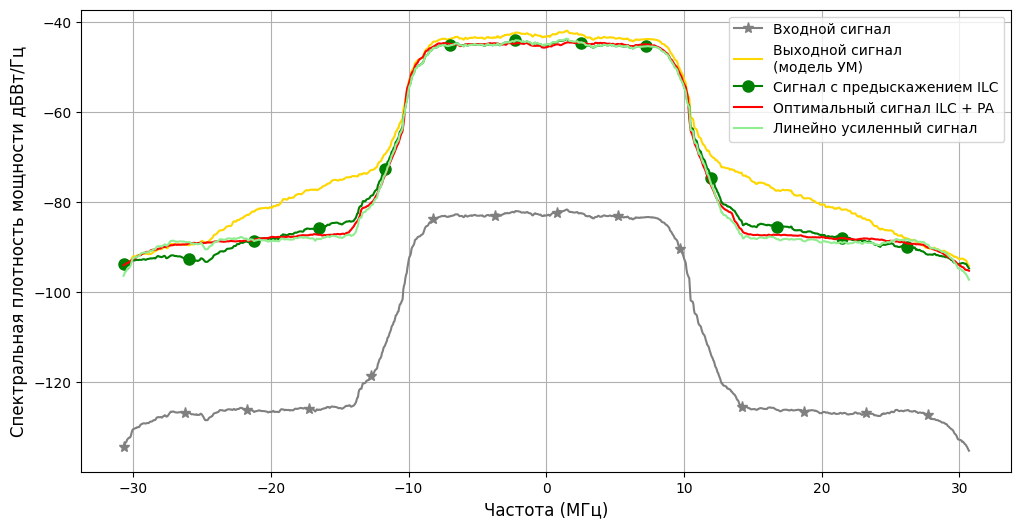

In [150]:
x_val = utils.iq_to_complex(container.val_input)

y_val_ilc = ilc_model(x_val)
y_val_ilc_pa = pa_model.forward(y_val_ilc).detach()

delay = ilc_model.max_delay

y_true = utils.iq_to_complex(container.val_output_target)

ilc_nmse = metrics.compute_nmse(y_val_ilc_pa, y_true[delay*2:])
print(F"NMSE: {ilc_nmse:.2f} dB")

ilc_acpr = metrics.calculate_acpr(y_val_ilc_pa, acpr_meter)
print(f"ilc ACPR: {ilc_acpr[0]:.2f} {ilc_acpr[1]:.2f}")

input_acpr = metrics.calculate_acpr(container.val_input[delay:], acpr_meter)
print(f"input ACPR: {input_acpr[0]:.2f} {input_acpr[1]:.2f}")

# ilc_acepr = metrics.compute_acepr(
#     measured=y_pred,
#     predicted=y_true,
#     fs=container.input_signal_fs,
#     main_bandwidth=container.bw_main_ch,
#     adjacent_bandwidth=container.bw_main_ch,
#     channel_offset=container.bw_main_ch,
#     nperseg=container.nperseg
# )

# print(f"ACEPR: {ilc_acepr:.2f} dB")


window_size = 50
normalization = False

freqs, spectrum_y_in = metrics.power_spectrum(container.val_input[delay:], container.input_signal_fs, container.nperseg, window_size, normalization=normalization)
_, spectrum_y_out = metrics.power_spectrum(container.val_output[delay:], container.input_signal_fs, container.nperseg, window_size, normalization=normalization)
_, spectrum_y_val_pa = metrics.power_spectrum(y_val_pa, container.input_signal_fs, container.nperseg, window_size, normalization=normalization)
_, spectrum_y_val_ilc = metrics.power_spectrum(y_val_ilc_pa, container.input_signal_fs, container.nperseg, window_size, normalization=normalization)
_, spectrum_u_k_pa = metrics.power_spectrum(u_k_pa, container.input_signal_fs, container.nperseg, window_size, normalization=normalization)
_, spectrum_y_val_target = metrics.power_spectrum(container.val_output_target, container.input_signal_fs, container.nperseg, window_size, normalization=normalization)


xlabel="Частота (МГц)"
ylabel= "Спектральная плотность мощности дБВт/Гц"
fontsize = 12
figsize=(12, 6)
markersize=8

plt.figure(figsize=figsize)

plt.plot(freqs / 1e6, spectrum_y_in, color='grey', label='Входной сигнал', marker = '*', markevery=90, markersize=markersize)
# plt.plot(freqs / 1e6, spectrum_y_out, color='black', label='Выходной сигнал', marker = '*', markevery=70, markersize=markersize)
plt.plot(freqs / 1e6, spectrum_y_val_pa, color='gold', label='Выходной сигнал \n(модель УМ)')
plt.plot(freqs / 1e6, spectrum_y_val_ilc, color='green', label='Сигнал с предыскажением ILC', marker='o', markevery=95, markersize=markersize)
plt.plot(freqs / 1e6, spectrum_u_k_pa, color='red', label='Оптимальный сигнал ILC + PA')
plt.plot(freqs / 1e6, spectrum_y_val_target, color='lightgreen', label='Линейно усиленный сигнал')


plt.xlabel(xlabel, fontsize=fontsize)
plt.ylabel(ylabel, fontsize=fontsize)
# plt.ylim(bottom=-122)
# plt.xticks(np.arange(-500, 600, 100))
plt.legend()
plt.grid()
plt.show()
